In [1]:
#Importing basic libraries
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load PGCB data
pgcb = pd.read_excel('PGCB_date_power_demand.xlsx')

#PGCB data is sorted, duplicates are removed and then sampled by hour
pgcb = pgcb.sort_values('datetime').drop_duplicates('datetime')
pgcb = pgcb.set_index('datetime').resample('h').mean(numeric_only=True).reset_index()

#Anomaly Detection and Smoothing is done through IQR Method
Q1 = pgcb['demand_mw'].quantile(0.25)
Q3 = pgcb['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
pgcb['demand_mw'] = pgcb['demand_mw'].clip(lower=lower_bound, upper=upper_bound)
pgcb['demand_mw'] = pgcb['demand_mw'].interpolate(method='linear')

In [3]:
#Load Economic Data
econ = pd.read_csv('economic_full_1.csv')

#Dataset is flipped. Initially every year represented a column. Now each row represents a year and the metrics are column headers
years = [str(y) for y in range(1960, 2025)]
econ = econ.melt(id_vars=['Indicator Name'], value_vars=years, var_name='year', value_name='val')
econ = econ.pivot_table(index='year', columns='Indicator Name', values='val').reset_index()
econ['time'] = econ['year'].astype(int)

In [4]:
#Load & Process Weather Data
weather = pd.read_excel("weather_data.xlsx", skiprows=3)

weather['time'] = pd.to_datetime(weather['time']).astype(int)

In [5]:
#Data Integration
pgcb['time'] = pgcb['datetime'].dt.year
df = pgcb.merge(econ, on='time', how='left')
df = df.merge(weather, on='time', how='left')
df = df.ffill().bfill()

In [6]:
#Feature Engineering

#Extracting time components
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

#Cyclical Encoding Hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

#Historical "Look Back" Features (Lags)
df['lag_1'] = df['demand_mw'].shift(1)   #Short-term Momentum
df['lag_2'] = df['demand_mw'].shift(2)   #Trend Direction
df['lag_24'] = df['demand_mw'].shift(24) #Repetetive Nature

# Rolling Aggregates/Moving Averages
df['roll_6_mean'] = df['demand_mw'].shift(1).rolling(window=6).mean() #Short-Term Trend
df['roll_24_mean'] = df['demand_mw'].shift(1).rolling(window=24).mean() #Daily Baseline

#Define Target - Next hour's demand
df['target'] = df['demand_mw'].shift(-1)


In [7]:
#Selecting target and filtering features that help in prediction
exclude_cols = ['datetime', 'year', 'month', 'hour', 'target', 'remarks', 'time']
features = [c for c in df.columns if c not in exclude_cols]

#Implementing IQR to fill the NaN's in the feature columns
for col in features+['target']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    df[col] = df[col].interpolate(method='linear')
    df[col] = df[col].fillna(df[col].mean())

In [8]:
#Modelling
#Separating Training and Testing dataset
train = df[df['datetime'].dt.year < 2025]
test = df[df['datetime'].dt.year == 2025]

x_train, y_train = train[features], train['target']
x_test, y_test = test[features], test['target']

#Using XGBoost Model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
#Evaluation
# Predictions and Primary Metric (MAPE)
y_pred = model.predict(x_test)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("MAPE: ", mape)

MAPE:  2.968650061458539


In [10]:
#Feature Visualizations

Text(0, 0.5, 'Demand (MW)')

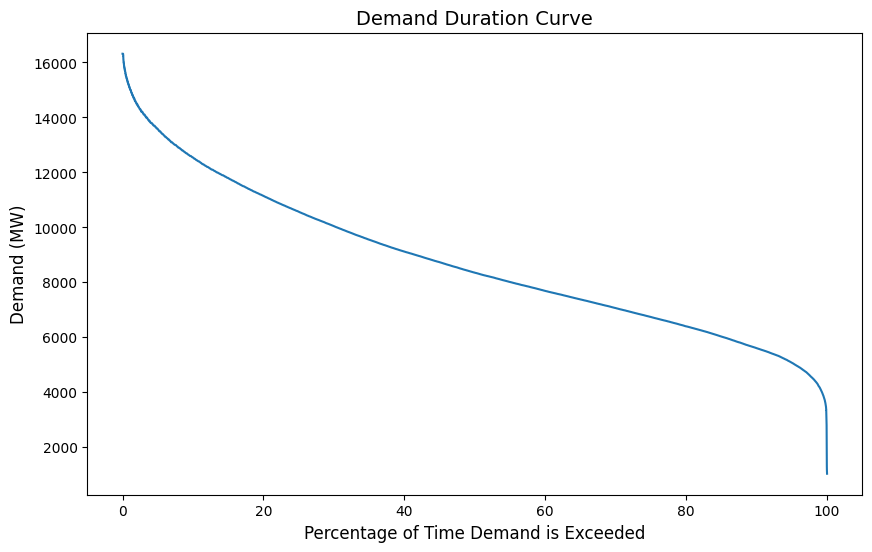

In [11]:
#1. Demand Duration Curve (DDC)

sorted_demand = np.sort(df['demand_mw'])[::-1]
x_percentile = np.arange(len(sorted_demand)) / len(sorted_demand) * 100

plt.figure(figsize=(10, 6))
plt.plot(x_percentile, sorted_demand)
plt.title('Demand Duration Curve', fontsize=14)
plt.xlabel('Percentage of Time Demand is Exceeded', fontsize=12)
plt.ylabel('Demand (MW)', fontsize=12)

Text(0, 0.5, '% Change in Average Power Demand (MW)')

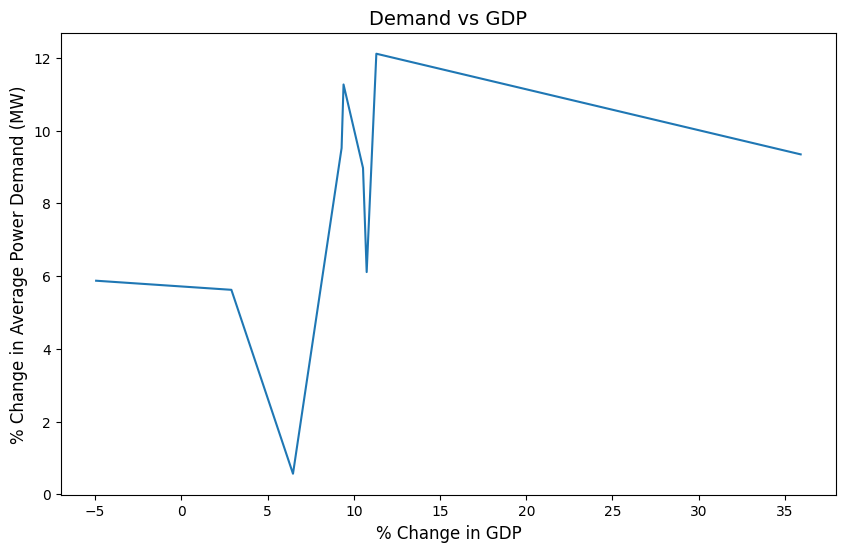

In [12]:
#2. Economic Elasticity: Demand vs. GDP

annual_df = df.groupby('year').agg({'demand_mw': 'mean', 'GDP (current US$)': 'first'}).reset_index()

annual_df['demand_pct_change'] = annual_df['demand_mw'].pct_change() * 100
annual_df['econ_pct_change'] = annual_df['GDP (current US$)'].pct_change() * 100
annual_df = annual_df.sort_values('econ_pct_change')

plt.figure(figsize=(10, 6))
plt.plot(annual_df['econ_pct_change'], annual_df['demand_pct_change'])
plt.title('Demand vs GDP', fontsize=14)
plt.xlabel('% Change in GDP', fontsize=12)
plt.ylabel('% Change in Average Power Demand (MW)', fontsize=12)